# Exercises XP: Introduction to LLMs

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells containing **TODO** markers need your input.


## 👩‍🏫👩🏿‍🏫 What you’ll learn
- Understand what Large Language Models (LLMs) can do.
- Review the Transformer architecture and the tokenization pipeline.
- Differentiate between pretraining and fine-tuning.
- Generate text with a pretrained language model.


## 🛠️ What you will create
- Markdown answers describing key NLP concepts.
- Python code that loads GPT-2 (or a similar causal LM) and performs basic tokenization and generation.


> **Learning point**
> Work through the exercises sequentially. Run installation cells only once, then focus on filling each TODO before executing the corresponding code.


## 🌟 Exercise 1 · What are Large Language Models?


### 1.1 Define LLMs
Large Language Models (LLMs) are a type of artificial intelligence program designed to understand and generate human-like text. They are built using deep learning, specifically a neural network architecture called the Transformer, and are trained on vast amounts of text data from the internet, books, and other sources.

LLMs are designed to perform a wide range of natural language processing tasks, including:

*   **Text Generation**: Writing articles, stories, poems, or even code.
*   **Summarization**: Condensing long texts into shorter, coherent summaries.
*   **Translation**: Translating text from one language to another.
*   **Question Answering**: Providing answers to questions based on a given text or general knowledge.
*   **Conversation**: Engaging in human-like dialogue.
*   **Sentiment Analysis**: Determining the emotional tone of a piece of text.
*   **Code Generation and Debugging**: Assisting with programming tasks.

Essentially, LLMs learn patterns, grammar, facts, and writing styles from the data they are trained on, allowing them to predict the next word in a sequence and, in turn, generate coherent and contextually relevant text.

### 1.2 Prefilled · install core libraries
Run once to install `transformers`, `torch`, and supporting utilities exactly as in the enoncé.


In [ ]:
%pip install --quiet transformers matplotlib --upgrade


### 1.3 Load GPT for causal text generation
Reuse the snippet from the platform: declare the model name, tokenizer, and model weights.


In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

model_name = 'gpt2'  # TODO: choose a causal LM checkpoint, e.g., 'gpt2'
tokenizer = AutoTokenizer.from_pretrained(model_name)   # TODO: load AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)       # TODO: load AutoModelForCausalLM.from_pretrained(model_name)

if None in (model_name, tokenizer, model):
    raise ValueError("Fill in model_name, tokenizer, and model before continuing.")

print(f"\nModel '{model_name}' loaded successfully!")
print("""
GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.
""")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model 'gpt2' loaded successfully!

GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.



## 🌟 Exercise 2 · Transformer Architecture and Tokenization


The tokenization process is the way in which raw text is converted into a sequence of numerical representations (tokens) that a language model can understand and process. Since models work with numbers, text needs to be broken down into smaller units.

Here's how it generally works:

1.  **Text Splitting**: The initial text is broken down into smaller pieces. This can be at the word level, subword level, or even character level, depending on the tokenizer.
2.  **Vocabulary Mapping**: Each unique piece (token) is assigned a unique numerical ID from a predefined vocabulary. This vocabulary is created during the training of the tokenizer on a large corpus of text.
3.  **Encoding**: The original text is then converted into a sequence of these numerical IDs.

For example, the sentence "Hello world!" might be tokenized into `['Hello', 'Ġworld', '!']`, and then each of these tokens would be mapped to a specific numerical ID, like `[15496, 2157, 995]`. Tokenization is a crucial step because it directly impacts how the model interprets and generates language.

Original Text: Large language models are fascinating.
Tokens: ['Large', 'Ġlanguage', 'Ġmodels', 'Ġare', 'Ġfascinating', '.']
Token IDs: [21968, 3303, 4981, 389, 13899, 13]


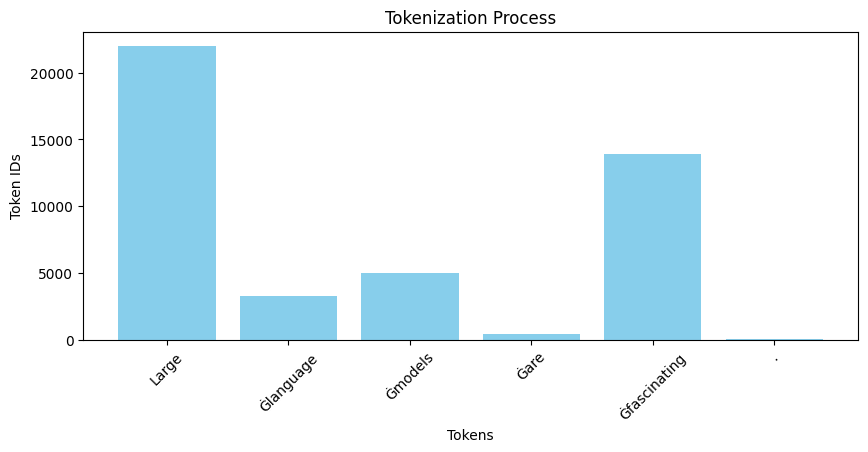

In [2]:
text = "Large language models are fascinating."  # TODO: provide a sentence of your choice
if text is None:
    raise ValueError("Define the variable `text` with a short sentence.")

tokens = tokenizer.tokenize(text)         # TODO: tokenize the input
token_ids = tokenizer.convert_tokens_to_ids(tokens)  # TODO: convert to ids

print(f"Original Text: {text}")
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")

x_label = "Tokens"  # TODO: label for the x-axis (e.g., "Tokens")
y_label = "Token IDs"  # TODO: label for the y-axis (e.g., "Token IDs")
title = "Tokenization Process"    # TODO: chart title

if None in (x_label, y_label, title):
    raise ValueError("Set x_label, y_label, and title before plotting.")

plt.figure(figsize=(10, 4))
plt.bar(tokens, token_ids, color="skyblue")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(rotation=45)
plt.show()

## 🌟 Exercise 3 · Token IDs and special prefixes


In [3]:
if 'tokens' not in globals() or 'token_ids' not in globals():
    raise ValueError("Run Exercise 2 to define `tokens` and `token_ids` first.")

# TODO: print the token along with its numeric id
for token, token_id in zip(tokens, token_ids):
    print(f"Token: '{token}', ID: {token_id}")

Token: 'Large', ID: 21968
Token: 'Ġlanguage', ID: 3303
Token: 'Ġmodels', ID: 4981
Token: 'Ġare', ID: 389
Token: 'Ġfascinating', ID: 13899
Token: '.', ID: 13


In GPT-style vocabularies (which often use Byte-Pair Encoding or BPE), the `Ġ` prefix (which is actually a Unicode character for a visible space, U+0120) indicates that the token it precedes is the beginning of a word. When a word is not at the start of a sentence or is preceded by a space, the tokenizer will include this prefix to signify that a space *should* come before this token if it were to be reconstructed into human-readable text.

For example:

*   `'Large'` does not have a `Ġ` prefix because it's typically the first word in a sentence or phrase and wouldn't be preceded by a space.
*   `'Ġlanguage'` has the `Ġ` prefix, indicating that it follows a space. So, when combining 'Large' and 'Ġlanguage', it becomes 'Large language'.

This method allows the tokenizer to handle different forms of words (e.g., 'running', 'runner') efficiently, as common word parts can be reused, and it helps in correctly reconstructing the original text with proper spacing after tokenization.

## 🌟 Exercise 4 : Pretraining vs. Fine-Tuning

In the context of Transformers and Large Language Models, pretraining and fine-tuning are two distinct but related phases in the model development lifecycle:

### 1. Pretraining

**What it is:** Pretraining is the initial phase where a large language model is trained on a massive dataset of text (and sometimes code or other modalities) using self-supervised learning tasks. This means the model learns patterns, grammar, semantics, and general world knowledge without explicit human labeling of the data. Common pretraining tasks include:
*   **Masked Language Modeling (MLM):** The model predicts masked-out words in a sentence (e.g., as in BERT).
*   **Causal Language Modeling (CLM):** The model predicts the next word in a sequence (e.g., as in GPT models).

**Purpose:** The goal of pretraining is to create a powerful, general-purpose language representation that can understand and generate human-like text across a wide range of topics and styles. During this phase, the model learns the fundamental statistical relationships within language.

**Characteristics:**
*   Requires enormous computational resources and vast amounts of data.
*   Produces a foundational model with broad capabilities but not specialized for any particular task.
*   Often performed by large research institutions or companies due to resource demands.

### 2. Fine-Tuning

**What it is:** Fine-tuning is the subsequent phase where a pretrained model is adapted to a specific downstream task with a smaller, task-specific labeled dataset. The model's already learned general knowledge is leveraged, and its weights are adjusted to perform well on the new, narrower task.

**Purpose:** The goal of fine-tuning is to specialize the pretrained model for a particular application (e.g., sentiment analysis, text summarization, question answering, translation) and improve its performance on that specific task.

**Characteristics:**
*   Requires significantly less data and computational resources compared to pretraining.
*   Uses a supervised learning approach, often with labeled examples for the target task.
*   Allows developers to customize powerful general models for their unique needs without building a model from scratch.
*   Often involves adding a small task-specific layer on top of the pretrained model's core architecture.

**Analogy:** You can think of pretraining as a student spending years in general education (learning math, history, science). Fine-tuning is like that same student then taking a specialized course or apprenticeship to become an expert in a specific profession (e.g., becoming a doctor or an engineer), leveraging their general knowledge but focusing on a particular skill set.

## 🌟 Exercise 4 · Generate simple text


Create a fresh prompt, run the generator, and observe how the model extends your sentence token by token.


In [4]:
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

input_text = "The quick brown fox"  # TODO: write a brand-new prompt
if input_text is None:
    raise ValueError("Set `input_text` before generating.")

gen_kwargs = {
    "max_new_tokens": 60,  # TODO: adjust if you want longer/shorter outputs
    "temperature": 0.8,    # TODO: tune sampling temperature
    "top_p": 0.95,
    "do_sample": True,
}

output_ids = generator(input_text, **gen_kwargs)  # TODO: call the generator
output_text = output_ids[0]["generated_text"]     # TODO: extract the text string

print(f"Input: {input_text}")
print(f"Generated Output: {output_text}")

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'temperature', 'max_new_tokens', 'top_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe

Input: The quick brown fox
Generated Output: The quick brown foxes are a perfect companion for your dog to chew on, as well as for your dog's food.

They are a great companion for your pet and pet food. They can be used as a treat for your dog, even if the dog is not going to be able to chew on it


Comparing the generated continuation with expectations can be insightful. For the prompt "The quick brown fox," a common expectation might be the completion "jumps over the lazy dog." However, the model generated a more elaborate text about foxes as companions and pet food.

This divergence from the common idiom highlights that LLMs, while powerful, generate text based on statistical patterns learned from their training data, not necessarily on human cultural references or common phrases unless they appear frequently in the training data in similar contexts. The generated text is coherent and grammatically correct, even if it's not the exact idiomatic continuation.

Regarding the parameters that change the style the most:

*   **`temperature`**: This is often considered the most impactful knob for controlling the *creativity* or *randomness* of the output. A higher `temperature` (e.g., 0.8 to 1.0+) leads to more diverse and surprising text, as the model is more willing to pick less probable words. A lower `temperature` (e.g., 0.2 to 0.5) makes the output more deterministic, focused, and conservative, often sticking to the most probable words. If you want less predictable or more imaginative responses, increase the temperature.

*   **`max_new_tokens`**: This parameter primarily controls the *length* of the generated output. A higher value will produce longer text, while a lower value will result in shorter, more concise completions. It doesn't directly influence the *style* of the text but rather its extent.

*   **`top_p` (nucleus sampling)**: This parameter also influences creativity by sampling from the smallest set of tokens whose cumulative probability exceeds the `top_p` value. It offers a balance between diversity and coherence. A higher `top_p` (e.g., 0.95) allows for more diverse word choices within the most probable set, while a lower `top_p` (e.g., 0.7 or 0.8) makes the model more conservative.

In summary, `temperature` and `top_p` are the main parameters to tune when you want to change the *style*, *creativity*, or *focus* of the generated text, with `temperature` often having the most noticeable effect on perceived randomness.

Here's a summary that can help you decide of how to fix these parameters:

![image.png](https://github.com/user-attachments/assets/a4c444d7-fab8-4f56-b7c7-00a15900cb5a)

## Summary of Completed Exercises

**Exercise 1: What are Large Language Models (LLM)?**
*   Defined LLMs, explaining their purpose and common applications in natural language processing.
*   Loaded a pre-trained GPT-2 model and its tokenizer, preparing for text generation tasks.

**Exercise 2: Transformer Architecture and Tokenization**
*   Explained the tokenization process, detailing how text is converted into numerical tokens for model input.
*   Tokenized a sample sentence and visualized the token IDs, demonstrating the process.

**Exercise 3: Understanding Token IDs and Special Prefixes**
*   Printed the token IDs for each token in the sample sentence.
*   Explained the significance of the 'Ġ' prefix in GPT-style tokenization, indicating word boundaries and handling spacing.

**Exercise 4: Generate Simple Text**
*   Generated text using the loaded GPT-2 model with a custom prompt.
*   Discussed the impact of generation parameters like `temperature`, `max_new_tokens`, and `top_p` on the style and length of the generated output.